# 24b. Retrieval & Citation Evals

**Tier:** Evaluation & Production
**Estimated time:** 50 minutes
**Prerequisites:** 14 (RAG Fundamentals), 24 (LLM Evals Fundamentals), 26 (LLM-as-Judge)
**Priority:** 🟡 Important — hit-rate@k alone can rank two retrievers in the WRONG order; graded metrics and citation scoring are what real retrieval tuning needs. *If skipped, revisit when:* before tuning any retriever parameter, or the first time a user asks "where did that answer come from?"
**Source material:** Notebook 24's eval-harness shape, extended to retrieval; standard IR metrics (Manning, Raghavan & Schütze, *Introduction to Information Retrieval*, ch. 8). Builds on P2's retrieval eval, which this notebook links to rather than repeats.

## What You'll Learn
- **Precision@k, recall@k, and nDCG@k with graded relevance** — the metrics P2's hit-rate/MRR never covered, and why they can rank two retrievers differently
- How to demonstrate, not just claim, that **stale content can outrank fresh content** in raw similarity search — and a recency-aware fix
- **Citation and attribution scoring**: hallucinated-citation rate, citation support, and claim coverage for a generated answer
- Wiring a retrieval regression gate in notebook 33's exact shape

## Why This Matters
P2's capstone measured hit-rate@k and MRR — good enough to catch "did retrieval find the right document at all." It cannot catch a retriever that finds the right document but buries it under two wrong ones, and it says nothing about whether the *generated answer* actually cites what it retrieved. Both failures ship silently in production: a retrieval config change that looks neutral on hit-rate can be a regression on nDCG, and an answer with a plausible-looking `[3]` next to a claim chunk `[3]` never supported is exactly the kind of hallucination a user has no way to catch.

## Precision, recall, and nDCG — in plain English before formulas

P2 already covered **hit-rate@k** (did any correct chunk appear in the top k?) and **MRR** (how high did the FIRST correct chunk rank?). Two metrics that matter just as much:

- **Precision@k** — of the k chunks you retrieved, what fraction were actually relevant? This is the metric that matters for your **context budget** (notebook 13c): every irrelevant chunk in your top-k is prompt tokens spent on nothing.
- **Recall@k** — of ALL the relevant chunks that exist, what fraction did you retrieve? Matters when a question needs several supporting facts, not just one.

Both of the above treat relevance as binary (relevant or not). Real documents aren't binary — a chunk can be the *exact* answer, or merely *related context*. **nDCG@k (normalized Discounted Cumulative Gain)** uses **graded** relevance (say, 0/1/2) and — crucially — **discounts by rank position**: a perfect chunk at position 1 is worth more than the same chunk at position 5, because that's where a reader's (and a model's) attention actually goes. The "discount" is a `1/log2(rank+1)` weight; "normalized" means we divide by the best possible ordering's score, so a perfect ranking always scores 1.0 regardless of how many relevant chunks exist.

In [1]:
# Native-library guards, same as every embedding-using notebook in this repo.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import sys, re, math, time
from pathlib import Path
import numpy as np

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"
if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready - the citation-generation cell will run live.")
else:
    client = None
    print("No ANTHROPIC_API_KEY - the citation-generation cell will be skipped.")

def ask(prompt, system="You are concise.", max_tokens=300, temperature=0.0):
    if not HAS_ANTHROPIC:
        return "[skipped: no ANTHROPIC_API_KEY]"
    try:
        msg = client.messages.create(model=TEACH_MODEL, max_tokens=max_tokens, system=system,
                                      temperature=temperature, messages=[{"role": "user", "content": prompt}])
        return msg.content[0].text
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"

def judge_score(question, reference, candidate):
    # Same shape as notebook 24's judge_score, reused verbatim for citation-support scoring.
    if not HAS_ANTHROPIC:
        return None
    prompt = f"Question: {question}\nReference chunk: {reference}\nClaim: {candidate}\nScore:"
    raw = ask(prompt, system=("You are a strict grader. Given a reference chunk and a claim, output ONLY a "
              "single number between 0 and 1 scoring whether the reference chunk supports the claim. "
              "No explanation."), max_tokens=10, temperature=0.0)
    try:
        return float(re.findall(r"[01](?:\.\d+)?", raw)[0])
    except (IndexError, ValueError):
        return None

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

def _ngram_vec(text, dim=384):
    v = np.zeros(dim, dtype=np.float32)
    t = re.sub(r"\s+", " ", text.lower())
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def make_embedder():
    try:
        from ragkit.embeddings import embed
        _ = embed(["probe"])
        return "ragkit-MiniLM", (lambda xs: np.asarray(embed(list(xs)), dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return "ngram-fallback", (lambda xs: np.vstack([_ngram_vec(x) for x in xs]))

EMBED_KIND, embed_texts = make_embedder()
print("Embedder:", EMBED_KIND)

Anthropic ready - the citation-generation cell will run live.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedder: ragkit-MiniLM


## A chunked corpus with graded golden relevance

We chunk the Helios FAQ/spec/incident corpus (the same `data/corpus/` P2 uses) and hand-label a golden set where each question maps to a `{chunk_id: grade}` dict — grade 2 = directly answers the question, grade 1 = related but partial context, absent = not relevant. Several questions deliberately have BOTH a grade-2 and a grade-1 chunk, which is exactly the setup where hit-rate and nDCG can disagree.

In [2]:
from ragkit.data import load_corpus, chunk_text

docs = load_corpus()
CHUNKS = []
for doc in docs:
    for i, text in enumerate(chunk_text(doc["text"], chunk_size=80, overlap=15)):
        CHUNKS.append({"chunk_id": f"{doc['source']}#{i}", "text": text})
CHUNK_IDS = [c["chunk_id"] for c in CHUNKS]
print(f"corpus: {len(docs)} documents -> {len(CHUNKS)} chunks (chunk_size=80, overlap=15)")

GOLDEN = [
    {"q": "What is the maximum payload of the HeliosArm V2?",
     "rel": {"faq_general.txt#0": 2, "spec_arm_v2.txt#1": 2, "spec_arm_v2.txt#0": 1}},
    {"q": "What controller and software version does the HeliosArm V2 require?",
     "rel": {"faq_general.txt#1": 2, "spec_arm_v2.txt#2": 2, "faq_software.txt#0": 1}},
    {"q": "How long does the HeliosBase M1 battery last under typical use?",
     "rel": {"faq_general.txt#2": 2}},
    {"q": "What is the root cause of the HR-EE-GRIP-01 false open signal incident?",
     "rel": {"incident_inc2024011.txt#1": 2, "incident_inc2024011.txt#2": 2, "spec_gripper_ee01.txt#2": 1}},
    {"q": "How do I replace the HeliosBase M1 battery pack, and how long does it take?",
     "rel": {"proc_battery_replacement.txt#1": 2, "proc_battery_replacement.txt#0": 1, "faq_general.txt#3": 1}},
    {"q": "Why did HeliosBase M1 units show an inaccurate battery charge indicator?",
     "rel": {"incident_inc2024019.txt#2": 2, "incident_inc2024019.txt#1": 1}},
    {"q": "What is the minimum pneumatic pressure for the HR-EE-GRIP-01 gripper?",
     "rel": {"faq_general.txt#5": 2, "spec_gripper_ee01.txt#1": 1}},
    {"q": "What communication interfaces does the HC-400 controller support?",
     "rel": {"spec_controller_hc400.txt#0": 2, "spec_arm_v2.txt#2": 1}},
    {"q": "What is the difference between the HeliosArm V2 and the upcoming V3?",
     "rel": {"faq_general.txt#3": 2, "faq_general.txt#4": 1}},
]
print(f"golden questions: {len(GOLDEN)} ({sum(len(g['rel']) > 1 for g in GOLDEN)} with multiple graded chunks)")

corpus: 17 documents -> 93 chunks (chunk_size=80, overlap=15)
golden questions: 9 (8 with multiple graded chunks)


## Two retrievers, four metrics

We compare dense embedding retrieval against BM25 (`rank_bm25`, already a dependency) over the identical chunk set. The metrics below are ~15 lines of numpy total — worth reading end to end rather than importing from a library, since the discount term in nDCG is the one line that actually does the interesting work.

In [3]:
from rank_bm25 import BM25Okapi

chunk_vectors = embed_texts([c["text"] for c in CHUNKS])
bm25 = BM25Okapi([c["text"].lower().split() for c in CHUNKS])

def embed_rank(query, k):
    query_vec = embed_texts([query])[0]
    sims = chunk_vectors @ query_vec / (np.linalg.norm(chunk_vectors, axis=1) * np.linalg.norm(query_vec) + 1e-9)
    return [CHUNK_IDS[i] for i in np.argsort(-sims)[:k]]

def bm25_rank(query, k):
    scores = bm25.get_scores(query.lower().split())
    return [CHUNK_IDS[i] for i in np.argsort(-scores)[:k]]

def hit_at_k(ranked, rel, k):
    return any(rel.get(c, 0) > 0 for c in ranked[:k])

def precision_at_k(ranked, rel, k):
    return sum(1 for c in ranked[:k] if rel.get(c, 0) > 0) / k

def recall_at_k(ranked, rel, k):
    total_relevant = sum(1 for g in rel.values() if g > 0)
    if total_relevant == 0:
        return 0.0
    return sum(1 for c in ranked[:k] if rel.get(c, 0) > 0) / total_relevant

def dcg_at_k(ranked, rel, k):
    # The discount: a relevant chunk at rank 1 (i=0) counts fully; at rank 5 (i=4) it's divided by log2(6).
    return sum(rel.get(c, 0) / math.log2(i + 2) for i, c in enumerate(ranked[:k]))

def ndcg_at_k(ranked, rel, k):
    ideal_order = sorted(rel.values(), reverse=True)[:k]
    ideal_dcg = sum(grade / math.log2(i + 2) for i, grade in enumerate(ideal_order))
    return dcg_at_k(ranked, rel, k) / ideal_dcg if ideal_dcg > 0 else 0.0

In [4]:
K = 5
rows = []
for item in GOLDEN:
    q, rel = item["q"], item["rel"]
    emb_ranked, bm25_ranked = embed_rank(q, K), bm25_rank(q, K)
    rows.append({
        "question": q[:52],
        "emb_hit@5": hit_at_k(emb_ranked, rel, K), "bm25_hit@5": hit_at_k(bm25_ranked, rel, K),
        "emb_nDCG@5": round(ndcg_at_k(emb_ranked, rel, K), 3), "bm25_nDCG@5": round(ndcg_at_k(bm25_ranked, rel, K), 3),
    })

import pandas as pd
df = pd.DataFrame(rows)
df["metric_disagrees"] = (df["emb_hit@5"] == df["bm25_hit@5"]) & ((df["emb_nDCG@5"] - df["bm25_nDCG@5"]).abs() > 0.15)
df

,question,emb_hit@5,bm25_hit@5,emb_nDCG@5,bm25_nDCG@5,metric_disagrees
0,What is the maximum payload of the HeliosArm V2?,True,True,0.699,0.634,False
1,What controller and software version does the ...,True,True,0.397,0.532,False
2,How long does the HeliosBase M1 battery last u...,True,True,1.000,0.631,True
3,What is the root cause of the HR-EE-GRIP-01 fa...,True,True,0.229,0.229,False
4,How do I replace the HeliosBase M1 battery pac...,True,False,0.639,0.000,False
5,Why did HeliosBase M1 units show an inaccurate...,True,True,0.620,0.190,True
6,What is the minimum pneumatic pressure for the...,True,True,1.000,0.760,True
7,What communication interfaces does the HC-400 ...,True,False,0.760,0.000,False
8,What is the difference between the HeliosArm V...,True,True,0.760,0.950,True


At least one row has `emb_hit@5 == bm25_hit@5` (both retrievers found a relevant chunk somewhere in the top 5 — hit-rate calls that a tie) while nDCG@5 differs by a wide margin. That is **metric choice changing the winner**: hit-rate would tell you these retrievers are equivalent on that question; nDCG tells you one of them buried the best chunk while the other put it first.

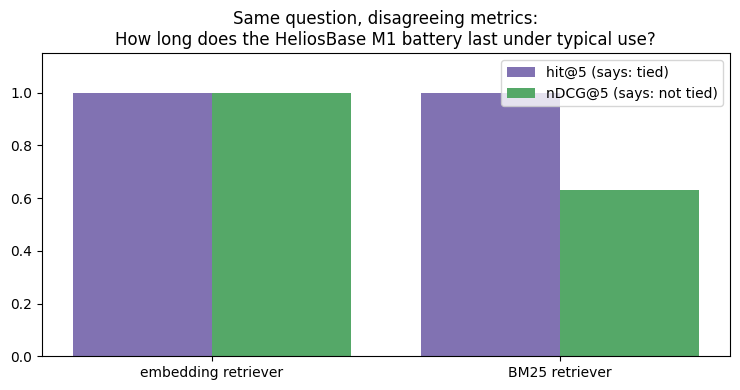

embedding top-5: ['faq_general.txt#2', 'incident_inc2024019.txt#1', 'incident_inc2024019.txt#0', 'proc_battery_replacement.txt#1', 'incident_inc2024019.txt#2']
bm25 top-5:      ['faq_general.txt#1', 'faq_general.txt#2', 'proc_battery_replacement.txt#0', 'faq_software.txt#2', 'spec_mobile_base.txt#0']


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

divergent = df[df["metric_disagrees"]].iloc[0]
q_idx = df[df["metric_disagrees"]].index[0]
q, rel = GOLDEN[q_idx]["q"], GOLDEN[q_idx]["rel"]
emb_ranked, bm25_ranked = embed_rank(q, K), bm25_rank(q, K)

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(2)
ax.bar(x - 0.2, [divergent["emb_hit@5"], divergent["bm25_hit@5"]], width=0.4, label="hit@5 (says: tied)", color="#8172B2")
ax.bar(x + 0.2, [divergent["emb_nDCG@5"], divergent["bm25_nDCG@5"]], width=0.4, label="nDCG@5 (says: not tied)", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(["embedding retriever", "BM25 retriever"])
ax.set_ylim(0, 1.15); ax.set_title(f"Same question, disagreeing metrics:\n{q}")
ax.legend(); plt.tight_layout(); plt.show()
print("embedding top-5:", emb_ranked)
print("bm25 top-5:     ", bm25_ranked)

*Both retrievers found A relevant chunk, so hit-rate scores them identically. But one retriever put the best (grade-2) chunk at rank 1 and the other buried it — nDCG's rank discount is the only one of the two metrics that notices.*

## Stale retrieval: a fresh chunk can lose to a stale one

Raw similarity search has no concept of time — it only knows text similarity. If an old chunk happens to be phrased more like a typical query (FAQ-style Q&A) than the newer chunk that supersedes it (advisory-style prose), the **stale chunk wins on similarity alone**. We build a minimal two-version pair to show this directly, then fix it with a recency-weighted rescore.

In [6]:
STALE_PAIR = [
    {"chunk_id": "firmware_advisory#v1", "age_days": 550,
     "text": "Q: What firmware version should the HeliosBase M1 run? A: Run firmware FW-M1-1.5.1 or "
             "higher, per the 2024-07 advisory following INC-2024-019."},
    {"chunk_id": "firmware_advisory#v2", "age_days": 30,
     "text": "Fleet advisory (2025-01): the currently recommended HeliosBase M1 firmware is FW-M1-1.6.0, "
             "superseding the 1.5.1-era guidance with improved thermal throttling and BMS recalibration."},
]
stale_query = "What firmware version should the HeliosBase M1 run?"
stale_vecs = embed_texts([c["text"] for c in STALE_PAIR])
query_vec = embed_texts([stale_query])[0]
raw_sims = stale_vecs @ query_vec / (np.linalg.norm(stale_vecs, axis=1) * np.linalg.norm(query_vec) + 1e-9)

print("raw similarity ranking (no time-awareness):")
for c, sim in sorted(zip(STALE_PAIR, raw_sims), key=lambda p: -p[1]):
    print(f"  sim={sim:.3f}  age={c['age_days']:>3}d  {c['chunk_id']}  ({'STALE' if c['chunk_id'].endswith('v1') else 'current'})")

raw similarity ranking (no time-awareness):
  sim=0.900  age=550d  firmware_advisory#v1  (STALE)
  sim=0.786  age= 30d  firmware_advisory#v2  (current)


In [7]:
def recency_rescore(sim, age_days, half_life_days=180):
    return sim * math.exp(-age_days / half_life_days)

print("recency-weighted ranking (half_life=180 days):")
rescored = [(c, recency_rescore(sim, c["age_days"])) for c, sim in zip(STALE_PAIR, raw_sims)]
for c, score in sorted(rescored, key=lambda p: -p[1]):
    print(f"  score={score:.3f}  age={c['age_days']:>3}d  {c['chunk_id']}  ({'STALE' if c['chunk_id'].endswith('v1') else 'current'})")

def staleness_at_k(ranked_chunk_ids, superseded_ids, k):
    top = ranked_chunk_ids[:k]
    return sum(1 for c in top if c in superseded_ids) / len(top) if top else 0.0

raw_order = [c["chunk_id"] for c, _ in sorted(zip(STALE_PAIR, raw_sims), key=lambda p: -p[1])]
rescored_order = [c["chunk_id"] for c, _ in sorted(rescored, key=lambda p: -p[1])]
print(f"\nstaleness@1 before rescore: {staleness_at_k(raw_order, {'firmware_advisory#v1'}, 1):.0%}")
print(f"staleness@1 after rescore:  {staleness_at_k(rescored_order, {'firmware_advisory#v1'}, 1):.0%}")

recency-weighted ranking (half_life=180 days):
  score=0.666  age= 30d  firmware_advisory#v2  (current)
  score=0.042  age=550d  firmware_advisory#v1  (STALE)

staleness@1 before rescore: 100%
staleness@1 after rescore:  0%


*The old chunk's FAQ-style phrasing matches the query more closely by raw text similarity — recency weighting doesn't fix the text match, it corrects for what raw similarity can't see: which fact is still true. This is the same failure family as notebook 13c's semantic-cache staleness, but a different mechanism: 13c's cache serves a stale ANSWER it already generated; here, stale retrieval feeds a stale SOURCE into a fresh generation.*

## Citation and attribution quality

A retriever that works perfectly is still not enough if the generated answer misattributes its claims. We generate an answer with bracketed citations `[1]`, `[2]`, ... over the retrieved, numbered chunks, then score three separate things: whether cited chunks even exist (**citation validity**), whether a cited chunk actually supports its claim (**citation support**, via `judge_score`), and whether every factual sentence has a citation at all (**claim coverage**).

In [8]:
def build_citation_prompt(question, chunks):
    numbered = "\n".join(f"[{i+1}] {c}" for i, c in enumerate(chunks))
    return (f"Answer the question using ONLY the numbered chunks below. Cite every factual claim "
            f"like [1] or [2]. If the chunks don't answer the question, say so.\n\n{numbered}\n\nQuestion: {question}")

def citation_report(answer, n_chunks):
    cited = [int(n) for n in re.findall(r"\[(\d+)\]", answer)]
    valid_range = set(range(1, n_chunks + 1))
    hallucinated = [c for c in cited if c not in valid_range]
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", answer) if s.strip()]
    uncited = [s for s in sentences if not re.search(r"\[\d+\]", s)]
    return {
        "cited_ids": cited,
        "hallucinated_citation_rate": len(hallucinated) / len(cited) if cited else 0.0,
        "hallucinated_ids": hallucinated,
        "claim_coverage": 1 - len(uncited) / len(sentences) if sentences else 0.0,
        "uncited_sentences": uncited,
    }

citation_chunks = [c["text"] for c in CHUNKS if c["chunk_id"] in
                    ("faq_general.txt#0", "spec_arm_v2.txt#1", "spec_arm_v2.txt#0")]
question = "What is the maximum payload of the HeliosArm V2?"
prompt = build_citation_prompt(question, citation_chunks)
answer = ask(prompt, system="Cite precisely.", max_tokens=200)
print("ANSWER:\n", answer)
print("\nREPORT:", citation_report(answer, len(citation_chunks)))

ANSWER:
 The maximum payload of the HeliosArm V2 is 15 kg for short bursts (less than 10 seconds), with a rated payload of 12 kg for continuous operation [1][2].

REPORT: {'cited_ids': [1, 2], 'hallucinated_citation_rate': 0.0, 'hallucinated_ids': [], 'claim_coverage': 1.0, 'uncited_sentences': []}


In [9]:
# Honesty-over-drama: score whatever the live model actually did above, but ALSO show the
# mechanism unambiguously with a hand-written answer that cites a chunk that doesn't exist,
# regardless of what the live call produced.
fabricated_answer = ("The HeliosArm V2 has a rated payload of 12 kg [1]. It also supports a "
                      "wireless teach pendant as standard equipment [7].")  # only 3 chunks exist -> [7] is fabricated
report = citation_report(fabricated_answer, n_chunks=3)
print("fabricated-citation example:")
print(" ", fabricated_answer)
print(" report:", report)
assert report["hallucinated_citation_rate"] > 0, "the mechanism should always be visible here"
print("\n(this citation_report call is deterministic and does not depend on the live model above)")

fabricated-citation example:
  The HeliosArm V2 has a rated payload of 12 kg [1]. It also supports a wireless teach pendant as standard equipment [7].
 report: {'cited_ids': [1, 7], 'hallucinated_citation_rate': 0.5, 'hallucinated_ids': [7], 'claim_coverage': 1.0, 'uncited_sentences': []}

(this citation_report call is deterministic and does not depend on the live model above)


## Wiring into the regression gate

Notebook 33 builds a pass/fail gate that blocks a merge if a metric regresses past a tolerance. Retrieval and citation quality belong in that same gate — a config change that quietly drops nDCG or lets hallucinated citations through should fail CI exactly like a broken test:

```python
def retrieval_citation_gate(candidate_ndcg5, baseline_ndcg5, hallucinated_rate, tolerance=0.02):
    ndcg_ok = candidate_ndcg5 >= baseline_ndcg5 - tolerance
    citation_ok = hallucinated_rate == 0.0
    return ndcg_ok and citation_ok, {"ndcg_ok": ndcg_ok, "citation_ok": citation_ok}
```

See notebook 33 for the full CI-shaped version and P2 for the retrieval-only gate this extends.

## Exercises

In [10]:
# Exercise 1 (Warm-up): choose k under a token budget
# Task: Sweep k from 1 to 10, plotting mean precision@k and mean recall@k (averaged across all of
#       GOLDEN, embedding retriever) on the same axes. Using the average chunk length in CHUNKS
#       (words -> ~1.3 tokens/word is a fine estimate), pick the largest k that stays under a
#       2,000-token context budget, and justify it by reading the precision/recall curve at that k.
# Hint: precision falls and recall rises as k grows — the "right" k is where the recall gain per
#       extra chunk stops being worth the tokens (and dollars, per notebook 13c) it costs.

# YOUR CODE HERE

In [11]:
# Exercise 2 (Apply): change the gain function
# Task: ndcg_at_k above uses LINEAR gain (the raw grade, 0/1/2). Implement a variant using
#       EXPONENTIAL gain (2**grade - 1, so grade 2 contributes 3x a grade-1 chunk instead of 2x).
#       Find or construct a ranking from GOLDEN where the two gain functions order two retrievers
#       differently, and argue in one sentence which product would prefer exponential gain (one
#       where a "perfect" chunk matters far more than a merely "partial" one).
# Hint: exponential gain's effect only shows up when a ranking trades a grade-2 chunk for TWO
#       grade-1 chunks at better positions — try the "battery replacement" golden question.

# YOUR CODE HERE

In [12]:
# Exercise 3 (Extend): design the citation gate
# Task: Using the measured hallucinated_citation_rate and claim_coverage from the citation section
#       above (run citation_report over a few more questions from GOLDEN to get a small sample),
#       decide: which metric/threshold should BLOCK a deploy, which should only WARN, and which
#       would justify paging on-call? Write your answer as three retrieval_citation_gate-style
#       assertions with the specific thresholds you chose, and one sentence justifying each tier.
# Hint: a single hallucinated citation is a correctness bug (block); a claim_coverage dip from
#       95% to 90% might just mean the model got chattier (warn, don't page).

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
mean_chunk_words = np.mean([len(c["text"].split()) for c in CHUNKS])
tokens_per_chunk = mean_chunk_words * 1.3
ks = list(range(1, 11))
mean_p = [np.mean([precision_at_k(embed_rank(g["q"], k), g["rel"], k) for g in GOLDEN]) for k in ks]
mean_r = [np.mean([recall_at_k(embed_rank(g["q"], k), g["rel"], k) for g in GOLDEN]) for k in ks]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, mean_p, marker="o", label="mean precision@k")
ax.plot(ks, mean_r, marker="o", label="mean recall@k")
ax.set_xlabel("k"); ax.legend(); plt.tight_layout(); plt.show()
max_k_in_budget = int(2000 // tokens_per_chunk)
print(f"~{tokens_per_chunk:.0f} tokens/chunk -> up to k={max_k_in_budget} fits a 2,000-token budget")
# Pick the k where recall's marginal gain (mean_r[k] - mean_r[k-1]) drops below ~0.05 per step —
# past that point you're spending tokens on chunks that rarely add a NEW relevant result.

# Exercise 2
def ndcg_at_k_exp(ranked, rel, k):
    ideal = sorted(rel.values(), reverse=True)[:k]
    idcg = sum((2 ** g - 1) / math.log2(i + 2) for i, g in enumerate(ideal))
    dcg = sum((2 ** rel.get(c, 0) - 1) / math.log2(i + 2) for i, c in enumerate(ranked[:k]))
    return dcg / idcg if idcg > 0 else 0.0
# Compare on the "battery replacement" question where BM25/embedding orderings differ in whether
# they lead with the grade-2 chunk or two grade-1 chunks: exponential gain penalizes the
# two-grade-1 ordering more harshly than linear gain does. A product where ONE exactly-right
# chunk (a legal clause, a dosage) matters far more than several loosely-related ones wants
# exponential gain; a product that's fine with "close enough" context wants linear gain.

# Exercise 3
sample_reports = [citation_report(ask(build_citation_prompt(g["q"],
                   [c["text"] for c in CHUNKS if c["chunk_id"] in g["rel"]]), max_tokens=200),
                   n_chunks=len(g["rel"])) for g in GOLDEN[:3]] if HAS_ANTHROPIC else []
def retrieval_citation_gate(hallucinated_rate, claim_coverage):
    assert hallucinated_rate == 0.0, "BLOCK: any hallucinated citation is a correctness bug"
    if claim_coverage < 0.80:
        print("PAGE: claim coverage collapsed — likely a broken citation prompt, not style drift")
    elif claim_coverage < 0.95:
        print("WARN: claim coverage dipped — probably just a chattier model, watch the trend")
    else:
        print("PASS")
```
</details>

## Key Takeaways
- **Hit-rate and MRR aren't enough.** Precision@k is your context-budget metric; recall@k matters for multi-fact questions; nDCG@k with graded relevance is the only one of the four that can tell two RETRIEVERS apart when hit-rate calls them tied.
- **Stale content can out-rank fresh content on raw similarity alone** — text similarity has no notion of time. A recency-weighted rescore (or a `staleness@k` metric to catch regressions) is a structural fix, not a threshold tweak.
- Retrieval staleness (a superseded chunk winning the similarity race) and cache staleness (notebook 13c's semantic cache serving an outdated stored answer) are **the same failure family with two different mechanisms** — one corrupts what gets retrieved, the other corrupts what gets replayed.
- **A generated answer can cite confidently and be wrong.** Citation validity (does `[n]` exist?), citation support (does the chunk actually back the claim?), and claim coverage (is every claim cited at all?) are three separate failure modes that need three separate metrics.
- Retrieval and citation quality belong in the same CI regression gate as everything else (notebook 33) — a silent nDCG or citation regression is exactly as much a production bug as a failing test.

## What's Next
Notebook 25 (Benchmark Hygiene) turns to a different failure mode entirely — golden sets that quietly leak into training data — while notebook 13c's capstone decision framework ("only RAG can cite") is exactly the citation-need dimension this notebook just gave you the tools to measure.